# 1. Q1 - Q2 Data Loading and Exploration

In [73]:
# data manipulation
import pandas as pd
import numpy as np

# machine learning
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score,recall_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# data visualization
import seaborn as sns
import matplotlib.pyplot as plt



In [74]:
# Reproducibility
STUDENT_ID = 25037242
np.random.seed(STUDENT_ID)

In [75]:
#Loading data into jupyter notebook using python

data_features = pd.read_csv('training_set_features.csv')
data_labels = pd.read_csv('training_set_labels.csv')

In [76]:
#Overview of data_features

data_features.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb


In [77]:
#Overview of data_labels

data_labels.head()

,respondent_id,h1n1_vaccine,seasonal_vaccine
0,0,0,0
1,1,0,1
2,2,0,0
3,3,0,1
4,4,0,0


In [78]:
#Merging feature and labels dataframes using merge on respondent_id primary key

df = data_features.merge(data_labels, on= 'respondent_id')
df

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,Own,Not in Labor Force,qufhixun,Non-MSA,0.0,0.0,NaN,NaN,0,0
26703,26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,Rent,Employed,lzgpxyit,"MSA, Principle City",1.0,0.0,fcxhlnwr,cmhcxjea,0,0
26704,26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,Own,NaN,lzgpxyit,"MSA, Not Principle City",0.0,0.0,NaN,NaN,0,1
26705,26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,Rent,Employed,lrircsnp,Non-MSA,1.0,0.0,fcxhlnwr,haliazsg,0,0


In [79]:
print(f'{df.shape[0]} rows and {df.shape[1]} columns')

26707 rows and 38 columns


In [80]:
# General Classes distribution
print(df['h1n1_vaccine'].value_counts(normalize=True))
print('')
print(df['seasonal_vaccine'].value_counts(normalize=True))

h1n1_vaccine
0    0.787546
1    0.212454
Name: proportion, dtype: float64

seasonal_vaccine
0    0.534392
1    0.465608
Name: proportion, dtype: float64


In [81]:
# Data Types
df.dtypes

respondent_id                    int64
h1n1_concern                   float64
h1n1_knowledge                 float64
behavioral_antiviral_meds      float64
behavioral_avoidance           float64
behavioral_face_mask           float64
behavioral_wash_hands          float64
behavioral_large_gatherings    float64
behavioral_outside_home        float64
behavioral_touch_face          float64
doctor_recc_h1n1               float64
doctor_recc_seasonal           float64
chronic_med_condition          float64
child_under_6_months           float64
health_worker                  float64
health_insurance               float64
opinion_h1n1_vacc_effective    float64
opinion_h1n1_risk              float64
opinion_h1n1_sick_from_vacc    float64
opinion_seas_vacc_effective    float64
opinion_seas_risk              float64
opinion_seas_sick_from_vacc    float64
age_group                          str
education                          str
race                               str
sex                      

In [82]:
# Data General Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_months       

In [83]:
print('Missing values per column:')

df.isnull().sum()

Missing values per column:


respondent_id                      0
h1n1_concern                      92
h1n1_knowledge                   116
behavioral_antiviral_meds         71
behavioral_avoidance             208
behavioral_face_mask              19
behavioral_wash_hands             42
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
health_insurance               12274
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
opinion_h1n1_sick_from_vacc      395
opinion_seas_vacc_effective      462
opinion_seas_risk                514
opinion_seas_sick_from_vacc      537
age_group                          0
education                       1407
race                               0
sex                                0
income_poverty                  4423
m

# Q3 Data Visualization and Preprocessing

''

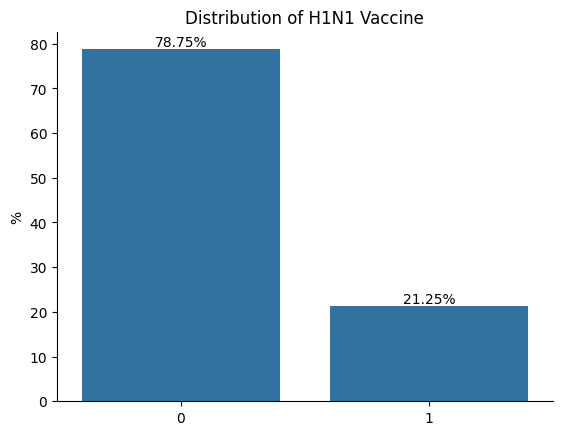

In [84]:
# 1.1 Distribution of h1n1_vaccine

ax = sns.countplot(df, x='h1n1_vaccine',stat='percent')
plt.xlabel('')
plt.ylabel('%')
plt.title('Distribution of H1N1 Vaccine')
sns.despine()

ax.bar_label(ax.containers[0],fmt='%.2f%%')

;

[Text(0, 0, '53.44%'), Text(0, 0, '46.56%')]

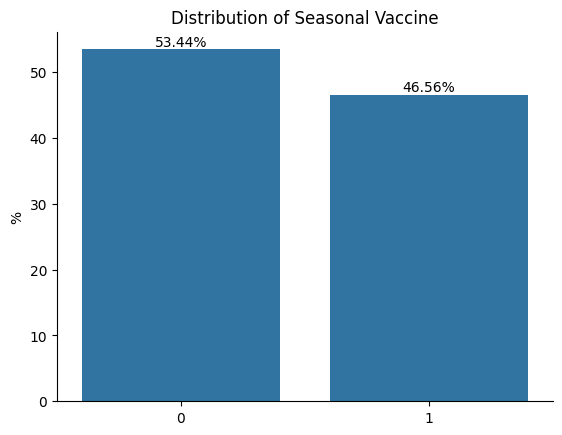

In [85]:
# 1.2 Distribution of Seasonal Vaccine

ax = sns.countplot(data=df,x='seasonal_vaccine',stat='percent')
plt.xlabel('')
plt.ylabel('%')
plt.title('Distribution of Seasonal Vaccine')
sns.despine();

ax.bar_label(ax.containers[0],fmt='%.2f%%')

Based on these plotted charts it is possible to notice that both have different behaviours when it comes to their distribution. The first one shows that a big part of the respondants did not take the H1N1 Vaccine whereas in contrast the Seasonal Vaccine is quite balanced in general. That being said it is possible to confirm our choice of AUC-ROC and F1-SCORE as evaluation metrics was correct for this project since the dataset is not well balanced data and it is needed to understand how well the model will be capable of correctly classify the attributes in general and not only focused on negative or positive but both.

In [86]:
df.isnull().sum().reset_index(name='null_count')

,index,null_count
0,respondent_id,0
1,h1n1_concern,92
2,h1n1_knowledge,116
3,behavioral_antiviral_meds,71
4,behavioral_avoidance,208
5,behavioral_face_mask,19
6,behavioral_wash_hands,42
7,behavioral_large_gatherings,87
8,behavioral_outside_home,82
9,behavioral_touch_face,128


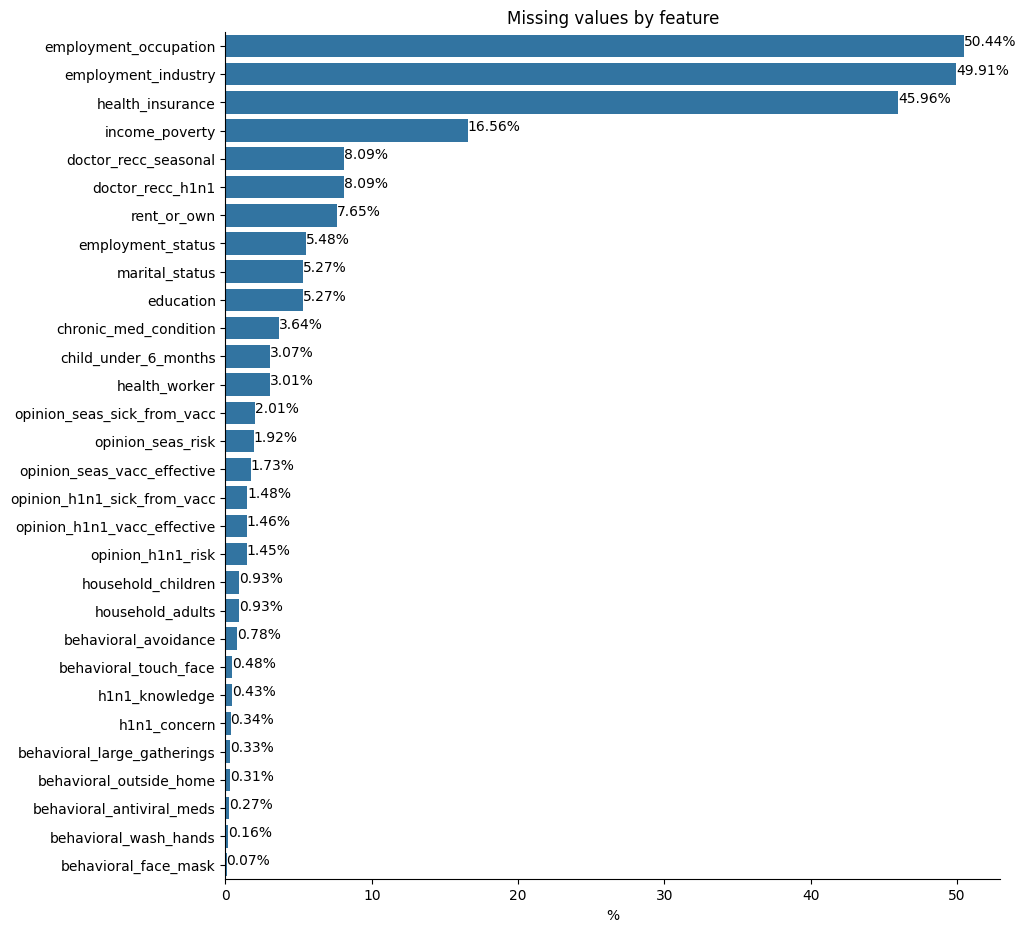

In [87]:
# 1.3 Missing values by feature

df_null_counts = df.isnull().sum().reset_index(name='null_count').rename(columns={'index':'feature'})
df_null_counts['nulls_percent'] = (df_null_counts['null_count']/len(df)) * 100
df_null_counts = df_null_counts.query('null_count>0').sort_values('nulls_percent',ascending=False)

fig, ax = plt.subplots(figsize=(10,11))


sns.barplot(df_null_counts,x= 'nulls_percent',y='feature', orient='h')
plt.title('Missing values by feature')
plt.ylabel('')
plt.xlabel('%')
sns.despine()

for i, v in enumerate(df_null_counts['nulls_percent']):
    ax.text(v,i,f'{v:.2f}%')


In [88]:
df['age_group'].value_counts()

age_group
65+ Years        6843
55 - 64 Years    5563
45 - 54 Years    5238
18 - 34 Years    5215
35 - 44 Years    3848
Name: count, dtype: int64

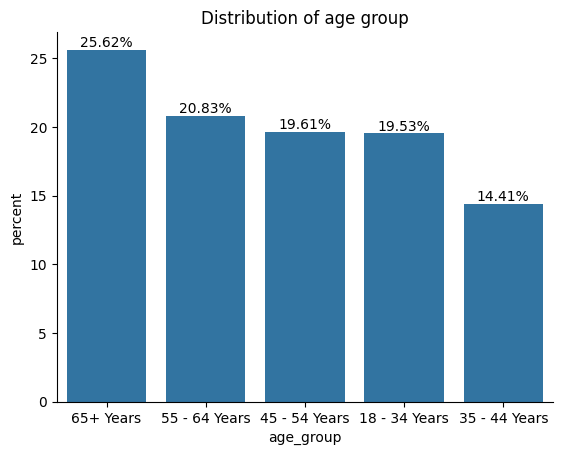

In [89]:

# 1.4 Distribution of age_group

ax = sns.countplot(data=df,x='age_group',stat='percent',order=df['age_group'].value_counts().index)
ax.set_title('Distribution of age group')
sns.despine()

ax.bar_label(ax.containers[0],fmt= '%.2f%%');


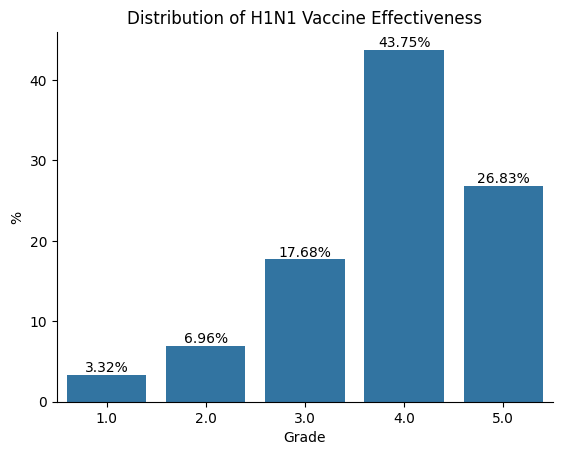

In [90]:
# 1.5 Distribution of opinion_h1n1_vacc_effective

ax = sns.countplot(df,x='opinion_h1n1_vacc_effective',stat='percent')

ax.set_title('Distribution of H1N1 Vaccine Effectiveness')
sns.despine()
ax.set_xlabel('Grade')
ax.set_ylabel('%')
ax.bar_label(ax.containers[0],fmt='%.2f%%');

In [91]:
df_groupedby = df.groupby(['doctor_recc_h1n1','h1n1_vaccine'])['h1n1_vaccine'].count().reset_index(name='uptake')
df_groupedby['total uptake'] = df_groupedby.groupby('doctor_recc_h1n1')['uptake'].transform('sum')
df_groupedby['total uptake percent'] = (df_groupedby['uptake']/df_groupedby['total uptake']) * 100
df_groupedby

,doctor_recc_h1n1,h1n1_vaccine,uptake,total uptake,total uptake percent
0,0.0,0,16529,19139,86.362924
1,0.0,1,2610,19139,13.637076
2,1.0,0,2529,5408,46.764053
3,1.0,1,2879,5408,53.235947


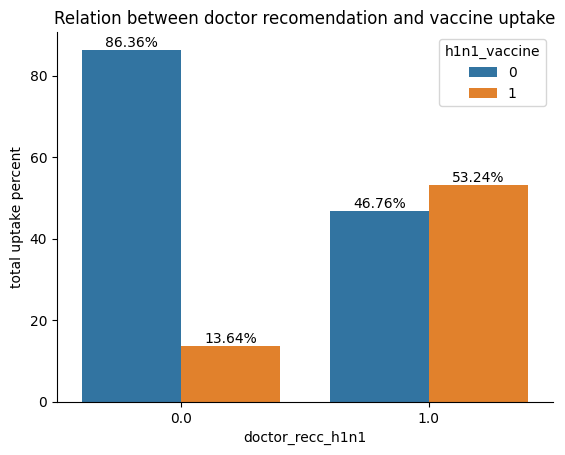

In [92]:
# 2.1 doctor_recc_h1n1 vs h1n1_vaccine

ax = sns.barplot(data=df_groupedby,x='doctor_recc_h1n1',y='total uptake percent',hue='h1n1_vaccine')

ax.bar_label(ax.containers[0],fmt='%.2f%%')
ax.bar_label(ax.containers[1],fmt='%.2f%%')
ax.set_title('Relation between doctor recomendation and vaccine uptake')
sns.despine()

In [93]:
df_groupedby = df.groupby(['doctor_recc_seasonal','seasonal_vaccine'])['seasonal_vaccine'].count().reset_index(name='uptake')
df_groupedby['total uptake'] = df_groupedby.groupby('doctor_recc_seasonal')['uptake'].transform('sum')
df_groupedby['total uptake percent'] = (df_groupedby['uptake']/df_groupedby['total uptake']) * 100
df_groupedby

,doctor_recc_seasonal,seasonal_vaccine,uptake,total uptake,total uptake percent
0,0.0,0,10756,16453,65.374096
1,0.0,1,5697,16453,34.625904
2,1.0,0,2117,8094,26.155177
3,1.0,1,5977,8094,73.844823


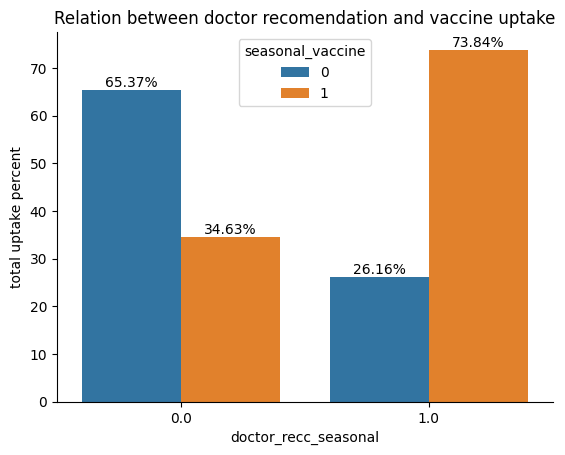

In [94]:
# 2.2 doctor_recc_seasonal vs seasonal_vaccine

ax = sns.barplot(data=df_groupedby,x='doctor_recc_seasonal',y='total uptake percent',hue='seasonal_vaccine')

ax.bar_label(ax.containers[0],fmt='%.2f%%')
ax.bar_label(ax.containers[1],fmt='%.2f%%')
ax.set_title('Relation between doctor recomendation and vaccine uptake')
sns.despine()

In [95]:
df['took_any_vaccine'] = ((df['h1n1_vaccine'] == 1) | (df['seasonal_vaccine'])).astype(int)

In [96]:
df_grouped = df.groupby(['age_group', 'took_any_vaccine'])['took_any_vaccine'].count().reset_index(name='total uptake')
df_grouped['grand total uptake '] = df_grouped.groupby('age_group')['total uptake'].transform('sum')
df_grouped['uptake percent'] = (df_grouped['total uptake']/df_grouped['grand total uptake ']) * 100
df_grouped

,age_group,took_any_vaccine,total uptake,grand total uptake,uptake percent
0,18 - 34 Years,0,3420,5215,65.580058
1,18 - 34 Years,1,1795,5215,34.419942
2,35 - 44 Years,0,2276,3848,59.147609
3,35 - 44 Years,1,1572,3848,40.852391
4,45 - 54 Years,0,2957,5238,56.452845
5,45 - 54 Years,1,2281,5238,43.547155
6,55 - 64 Years,0,2558,5563,45.982384
7,55 - 64 Years,1,3005,5563,54.017616
8,65+ Years,0,2084,6843,30.454479
9,65+ Years,1,4759,6843,69.545521


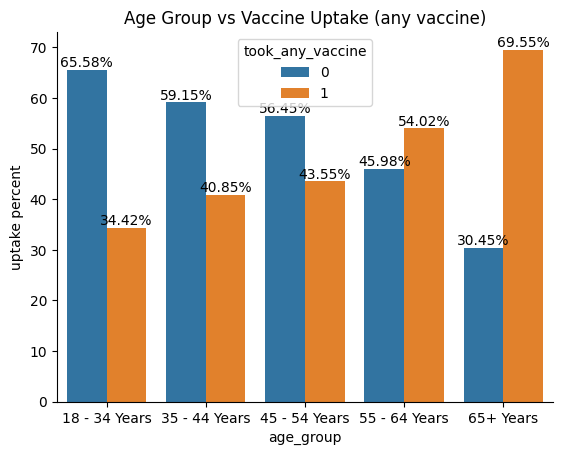

In [97]:
# 2.3 age_group vs took_any_vaccine

ax = sns.barplot(data=df_grouped,x='age_group',y='uptake percent',hue='took_any_vaccine')

ax.set_title('Age Group vs Vaccine Uptake (any vaccine)')
sns.despine()

ax.bar_label(ax.containers[0],fmt='%.2f%%')
ax.bar_label(ax.containers[1],fmt='%.2f%%');

In [98]:
df_grouped = df.groupby(['health_worker','took_any_vaccine'])['took_any_vaccine'].count().reset_index(name='total_uptake')
df_grouped['grand_total'] = df_grouped.groupby('health_worker')['total_uptake'].transform('sum')
df_grouped['total percent'] = (df_grouped['total_uptake'] / df_grouped['grand_total']) * 100
df_grouped

,health_worker,took_any_vaccine,total_uptake,grand_total,total percent
0,0.0,0,11930,23004,51.860546
1,0.0,1,11074,23004,48.139454
2,1.0,0,904,2899,31.183167
3,1.0,1,1995,2899,68.816833


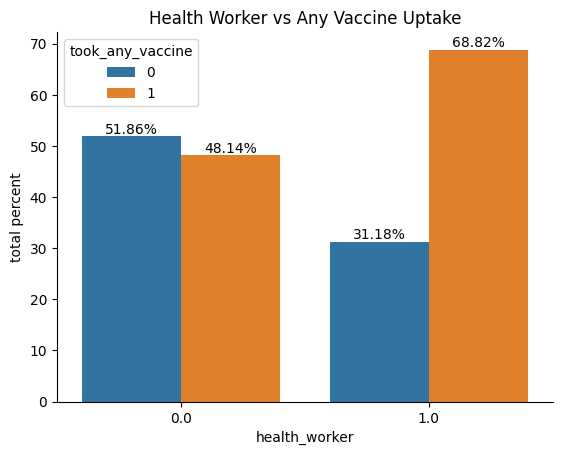

In [99]:
# 2.4 health_worker vs took_any_vaccine

ax = sns.barplot(data=df_grouped,x='health_worker',y='total percent',hue='took_any_vaccine')

ax.set_title('Health Worker vs Any Vaccine Uptake')
ax.bar_label(ax.containers[0],fmt='%.2f%%')
ax.bar_label(ax.containers[1],fmt='%.2f%%')
sns.despine()

In [100]:
df_grouped = df.groupby(['opinion_h1n1_vacc_effective','took_any_vaccine'])['took_any_vaccine'].count().reset_index(name='total')
df_grouped['grand_total'] = df_grouped.groupby('opinion_h1n1_vacc_effective')['total'].transform('sum')
df_grouped['total_percent'] = (df_grouped['total'] / df_grouped['grand_total']) * 100
df_grouped

,opinion_h1n1_vacc_effective,took_any_vaccine,total,grand_total,total_percent
0,1.0,0,686,886,77.426637
1,1.0,1,200,886,22.573363
2,2.0,0,1346,1858,72.443488
3,2.0,1,512,1858,27.556512
4,3.0,0,2640,4723,55.896676
5,3.0,1,2083,4723,44.103324
6,4.0,0,6058,11683,51.853120
7,4.0,1,5625,11683,48.146880
8,5.0,0,2339,7166,32.640246
9,5.0,1,4827,7166,67.359754


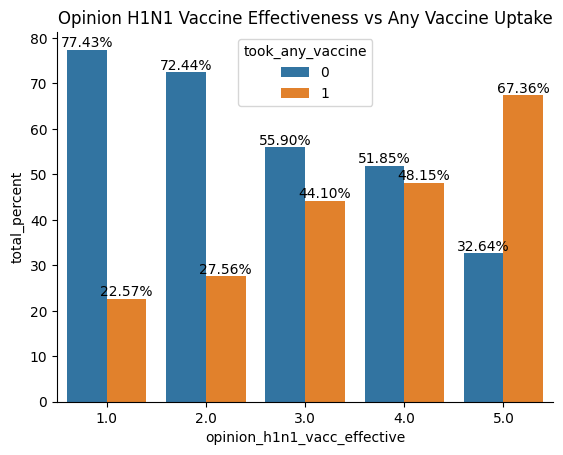

In [101]:
# 2.5.1 opinion_h1n1_vaccine_effectiviness vs took_any_vaccine

ax = sns.barplot(data=df_grouped,x='opinion_h1n1_vacc_effective',y='total_percent',hue='took_any_vaccine')

ax.set_title('Opinion H1N1 Vaccine Effectiveness vs Any Vaccine Uptake')
sns.despine()
ax.bar_label(ax.containers[0],fmt='%.2f%%')
ax.bar_label(ax.containers[1],fmt='%.2f%%');

In [102]:
df_grouped = df.groupby(['opinion_seas_vacc_effective','took_any_vaccine'])['took_any_vaccine'].count().reset_index(name='total')
df_grouped['grand total'] = df_grouped.groupby('opinion_seas_vacc_effective')['total'].transform('sum')
df_grouped['total_percent'] = (df_grouped['total']/df_grouped['grand total']) * 100
df_grouped

,opinion_seas_vacc_effective,took_any_vaccine,total,grand total,total_percent
0,1.0,0,997,1221,81.654382
1,1.0,1,224,1221,18.345618
2,2.0,0,1793,2206,81.278332
3,2.0,1,413,2206,18.721668
4,3.0,0,834,1216,68.585526
5,3.0,1,382,1216,31.414474
6,4.0,0,6781,11629,58.311119
7,4.0,1,4848,11629,41.688881
8,5.0,0,2628,9973,26.351148
9,5.0,1,7345,9973,73.648852


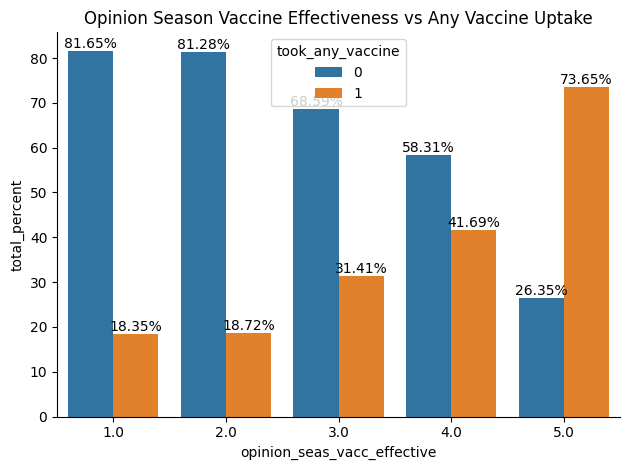

In [103]:
# 2.5.2 opinion_season_vaccine_effectiviness vs took_any_vaccine

ax = sns.barplot(data=df_grouped,x='opinion_seas_vacc_effective',y='total_percent',hue='took_any_vaccine')

ax.set_title('Opinion Season Vaccine Effectiveness vs Any Vaccine Uptake')
sns.despine()

ax.bar_label(ax.containers[0],fmt='%.2f%%')
ax.bar_label(ax.containers[1],fmt='%.2f%%');
plt.tight_layout()

## Preprocessing

In [104]:
# Creating a copy of the data frame to keep the original one untouched

df_model = df.copy()

In [105]:
# Dropping columns that have a high amount of missing values + respondend_id

cols_to_drop = ['employment_industry', 'employment_occupation', 'health_insurance','respondent_id']
df_model = df_model.drop(cols_to_drop,axis='columns')

In [106]:
# Validating if the columns have been dropped

print(df.shape)
print(df_model.shape)

(26707, 39)
(26707, 35)


In [107]:
# Setting targets

target_columns = ['h1n1_vaccine','seasonal_vaccine']

X = df_model.drop(target_columns,axis='columns')
y = df_model[target_columns]


In [108]:
# Validating if the columns have been dropped

print(X.shape)
print(y.shape)

(26707, 33)
(26707, 2)


In [109]:
#Checking what different columns types there are in the dataframe

X.dtypes.value_counts()

float64    22
str        10
int64       1
Name: count, dtype: int64

In [110]:
# Identifying categoricals and numericals columns

categorical_columns = X.select_dtypes(include='str').columns.to_list()
numerical_columns = X.select_dtypes(exclude='str').columns.to_list()


print(categorical_columns)
print()
print(numerical_columns)


['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa']

['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children', 'took_any_vaccine']


In [111]:
# Train, Validation and Test

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=STUDENT_ID,
    stratify=y['h1n1_vaccine']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state= STUDENT_ID,
    stratify=y_temp['h1n1_vaccine']
)


In [112]:
# Setting up pipeline for categorical columns

categorical_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

print(categorical_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])


In [113]:
# Setting up numeric pipeline

numeric_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [114]:
# Mounting preprocessor

preprocessor = ColumnTransformer([
    ('cat',categorical_pipeline,categorical_columns),
    ('num',numeric_pipeline,numerical_columns)
])

In [115]:
# Applying preprocessor on datasets

X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)

# Q4 - Modelling and GridSearchCV

In [116]:
# Creating baseline models

lr_h1n1_base = LogisticRegression(random_state=STUDENT_ID, max_iter=1000)
lr_seasonal_base = LogisticRegression(random_state=STUDENT_ID, max_iter=1000)

In [117]:
# Training baseline models

lr_h1n1_base.fit(X_train,y_train['h1n1_vaccine'])
lr_seasonal_base.fit(X_train,y_train['seasonal_vaccine'])

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",25037242
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [118]:
# Getting positive probabilities of targets for ROC-AUC calculation

prob_h1n1_val_base = lr_h1n1_base.predict_proba(X_val)[:,1]
prob_seasonal_val_base = lr_seasonal_base.predict_proba(X_val)[:,1]

In [119]:
#Turning positive probabilities into binaries options for F1-SCORE calculation.

pred_h1n1_val_base = (prob_h1n1_val_base>0.5).astype(int)
pred_seasonal_val_base = (prob_seasonal_val_base>0.5).astype(int)

In [120]:
# Calculating ROC-AUC score using positive probabilities for both targets

roc_auc_h1n1_score = roc_auc_score(y_val['h1n1_vaccine'],prob_h1n1_val_base)
roc_auc_seasonal_score = roc_auc_score(y_val['seasonal_vaccine'],prob_seasonal_val_base)

In [121]:
# Calculating F1-SCORE using binary prediction for both targets

f1_h1n1_base = f1_score(y_val['h1n1_vaccine'],pred_h1n1_val_base)
f1_seasonal_base = f1_score(y_val['seasonal_vaccine'],pred_seasonal_val_base)

In [122]:
#Classification report for both target and analysis of some of the evalution metrics

report_h1n1_base = classification_report(y_val['h1n1_vaccine'],pred_h1n1_val_base)
report_seasonal_base = classification_report(y_val['seasonal_vaccine'],pred_seasonal_val_base)

print('Classification Report H1N1 Base')
print(report_h1n1_base)
print()
print('Classification Report Seasonal Base')
print(report_seasonal_base)

Classification Report H1N1 Base
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      4207
           1       0.70      0.60      0.65      1135

    accuracy                           0.86      5342
   macro avg       0.80      0.77      0.78      5342
weighted avg       0.86      0.86      0.86      5342


Classification Report Seasonal Base
              precision    recall  f1-score   support

           0       0.99      0.94      0.97      2858
           1       0.94      0.99      0.97      2484

    accuracy                           0.97      5342
   macro avg       0.97      0.97      0.97      5342
weighted avg       0.97      0.97      0.97      5342



In [123]:
# calculating precision, recall and accuracy manually for both targets to build the dataframe

precision_h1n1_base = precision_score(y_val['h1n1_vaccine'],pred_h1n1_val_base)
recall_h1n1_base = recall_score(y_val['h1n1_vaccine'],pred_h1n1_val_base)
accuracy_h1n1_base = accuracy_score(y_val['h1n1_vaccine'], pred_h1n1_val_base)

precision_seasonal_base = precision_score(y_val['seasonal_vaccine'],pred_seasonal_val_base)
recall_seasonal_base = recall_score(y_val['seasonal_vaccine'],pred_seasonal_val_base)
accuracy_seasonal_base = accuracy_score(y_val['seasonal_vaccine'], pred_seasonal_val_base)



In [124]:
# Building baseline results dataframe

baseline_results = pd.DataFrame({
    'target': ['h1n1_vaccine','seasonal_vaccine'],
    'ROC-AUC':[roc_auc_h1n1_score,roc_auc_seasonal_score],
    'F1-SCORE':[f1_h1n1_base,f1_seasonal_base],
    'precision':[precision_h1n1_base,precision_seasonal_base],
    'recall': [recall_h1n1_base,recall_seasonal_base],
    'accuracy':[accuracy_h1n1_base,accuracy_seasonal_base]
})

baseline_results = baseline_results.round(4)
baseline_results

,target,ROC-AUC,F1-SCORE,precision,recall,accuracy
0,h1n1_vaccine,0.9273,0.6489,0.7041,0.6018,0.8617
1,seasonal_vaccine,0.9880,0.9658,0.9391,0.9940,0.9672


In [125]:
# Tuning the model usel GridSearchCV for h1n1 target

param_grid = {
    'C':[0.01,0.1,1,10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_h1n1 = GridSearchCV(
    estimator=LogisticRegression(random_state=STUDENT_ID,max_iter=1000),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_h1n1.fit(X_train,y_train['h1n1_vaccine'])

c:\Users\enriq\OneDrive\Documentos\ccda-applied-machine-learning\assignments\predict_H1N1_and_seasonal_flu_vaccines\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...tate=25037242)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displa

In [126]:
# Best h1n1 tuned model through GridSearchCV

print('Best parameters for H1N1:')
print(grid_h1n1.best_params_)

print()
print('Best cross-validation ROC-AUC for h1n1:')
print(grid_h1n1.best_score_)

h1n1_tuned = grid_h1n1.best_estimator_

Best parameters for H1N1:
{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}

Best cross-validation ROC-AUC for h1n1:
0.9299347892710171


In [127]:
# Testing new model on validation dataset

prob_h1n1_val_tuned = h1n1_tuned.predict_proba(X_val)[:,1]
pred_h1n1_val_tuned = (prob_h1n1_val_tuned>0.5).astype(int)


In [128]:
# Evaluation metrics for tuned h1n1 model

roc_auc_h1n1_tuned = roc_auc_score(y_val['h1n1_vaccine'],prob_h1n1_val_tuned)
f1_h1n1_tuned = f1_score(y_val['h1n1_vaccine'],pred_h1n1_val_tuned)
precision_h1n1_tuned = precision_score(y_val['h1n1_vaccine'],pred_h1n1_val_tuned)
recall_h1n1_tuned = recall_score(y_val['h1n1_vaccine'],pred_h1n1_val_tuned)
accuracy_h1n1_tuned = accuracy_score(y_val['h1n1_vaccine'],pred_h1n1_val_tuned)

report_h1n1_tuned = classification_report(y_val['h1n1_vaccine'],pred_h1n1_val_tuned)

print('Classification Report H1N1 Tuned')
print(report_h1n1_tuned)

Classification Report H1N1 Tuned
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      4207
           1       0.71      0.60      0.65      1135

    accuracy                           0.86      5342
   macro avg       0.80      0.77      0.78      5342
weighted avg       0.86      0.86      0.86      5342



In [129]:
# Now doing the same use of GridSearchCV to tune the model for seasonal vaccine

grid_seasonal = GridSearchCV(
    estimator=LogisticRegression(random_state=STUDENT_ID,max_iter=1000),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1
)

grid_seasonal.fit(X_train,y_train['seasonal_vaccine'])

c:\Users\enriq\OneDrive\Documentos\ccda-applied-machine-learning\assignments\predict_H1N1_and_seasonal_flu_vaccines\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...tate=25037242)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;-

In [130]:
# Checking the best parameters and score for the model

print('Best parameters for seasonal:')
print(grid_seasonal.best_params_)
print()
print('Cross validation ROC-AUC for seasonal')
print(grid_seasonal.best_score_)

seasonal_tuned = grid_seasonal.best_estimator_

Best parameters for seasonal:
{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}

Cross validation ROC-AUC for seasonal
0.9670471193379571


In [131]:
# Prediction for tuned seasonal model

prob_seasonal_val_tuned = seasonal_tuned.predict_proba(X_val)[:,1]
pred_seasonal_val_tuned = (prob_seasonal_val_tuned>0.5).astype(int)

In [132]:
# Evaluation metris for seasonal tuned model using validation dataset:

roc_auc_seasonal_tuned = roc_auc_score(y_val['seasonal_vaccine'],prob_seasonal_val_tuned)
f1_seasonal_tuned = f1_score(y_val['seasonal_vaccine'],pred_seasonal_val_tuned)
precision_seasonal_tuned = precision_score(y_val['seasonal_vaccine'],pred_seasonal_val_tuned)
accuracy_seasonal_tuned = accuracy_score(y_val['seasonal_vaccine'],pred_seasonal_val_tuned)
recall_seasonal_tuned = recall_score(y_val['seasonal_vaccine'],pred_seasonal_val_tuned)

report_seasonal_tuned = classification_report(y_val['seasonal_vaccine'],pred_seasonal_val_tuned)

print('Classification report for seasonal vaccine tuned: ')
print(report_seasonal_tuned)

Classification report for seasonal vaccine tuned: 
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      2858
           1       0.94      1.00      0.97      2484

    accuracy                           0.97      5342
   macro avg       0.97      0.97      0.97      5342
weighted avg       0.97      0.97      0.97      5342



In [133]:
# Gathering all evaluation metrics for both vaccines using tuned model

tuned_results = pd.DataFrame({
    'target':['h1n1_vaccine','seasonal_vaccine'],
    'roc_auc_val':[roc_auc_h1n1_tuned,roc_auc_seasonal_tuned],
    'f1_score_val':[f1_h1n1_tuned,f1_seasonal_tuned],
    'precision_val':[precision_h1n1_tuned,precision_seasonal_tuned],
    'accuracy_val':[accuracy_h1n1_tuned,accuracy_seasonal_tuned],
    'recall_val':[recall_h1n1_tuned,recall_seasonal_tuned]
})

tuned_results = tuned_results.round(4)
tuned_results

,target,roc_auc_val,f1_score_val,precision_val,accuracy_val,recall_val
0,h1n1_vaccine,0.9273,0.6491,0.7107,0.8628,0.5974
1,seasonal_vaccine,0.9882,0.9660,0.9385,0.9674,0.9952


In [134]:
# Comparing tuned and baseline results

baseline_results['model'] = 'baseline'
tuned_results['model'] = 'tuned'

comparing_results = pd.concat([baseline_results,tuned_results],axis=0)
comparing_results

,target,ROC-AUC,F1-SCORE,precision,recall,accuracy,model,roc_auc_val,f1_score_val,precision_val,accuracy_val,recall_val
0,h1n1_vaccine,0.9273,0.6489,0.7041,0.6018,0.8617,baseline,NaN,NaN,NaN,NaN,NaN
1,seasonal_vaccine,0.9880,0.9658,0.9391,0.9940,0.9672,baseline,NaN,NaN,NaN,NaN,NaN
0,h1n1_vaccine,NaN,NaN,NaN,NaN,NaN,tuned,0.9273,0.6491,0.7107,0.8628,0.5974
1,seasonal_vaccine,NaN,NaN,NaN,NaN,NaN,tuned,0.9882,0.9660,0.9385,0.9674,0.9952


In [135]:
# Finally using the test set in the model

prob_h1n1_test_final = h1n1_tuned.predict_proba(X_test)[:,1]
pred_h1n1_test_final = (prob_h1n1_test_final>0.5).astype(int)

prob_seasonal_test_final = seasonal_tuned.predict_proba(X_test)[:,1]
pred_seasonal_test_final = (prob_seasonal_test_final>0.5).astype(int)

In [136]:
# Evaluation metrics for the final test

roc_auc_h1n1_test = roc_auc_score(y_test['h1n1_vaccine'],prob_h1n1_test_final)
f1_h1n1_test = f1_score(y_test['h1n1_vaccine'],pred_h1n1_test_final)
precision_h1n1_test = precision_score(y_test['h1n1_vaccine'],pred_h1n1_test_final)
accuracy_h1n1_test = accuracy_score(y_test['h1n1_vaccine'],pred_h1n1_test_final)
recall_h1n1_test = recall_score(y_test['h1n1_vaccine'],pred_h1n1_test_final)

roc_auc_seasonal_test = roc_auc_score(y_test['seasonal_vaccine'],prob_seasonal_test_final)
f1_seasonal_test = f1_score(y_test['seasonal_vaccine'],pred_seasonal_test_final)
precision_seasonal_test = precision_score(y_test['seasonal_vaccine'],pred_seasonal_test_final)
accuracy_seasonal_test = accuracy_score(y_test['seasonal_vaccine'],pred_seasonal_test_final)
recall_seasonal_test = recall_score(y_test['seasonal_vaccine'],pred_seasonal_test_final)

report_h1n1_test = classification_report(y_test['h1n1_vaccine'],pred_h1n1_test_final)
report_seasonal_test = classification_report(y_test['seasonal_vaccine'],pred_seasonal_test_final)

print('H1N1 classification report for test dataset:')
print(report_h1n1_test)
print()
print('Seasonal classification report for dataset')
print(report_seasonal_test)

H1N1 classification report for test dataset:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92      4207
           1       0.71      0.63      0.66      1135

    accuracy                           0.87      5342
   macro avg       0.80      0.78      0.79      5342
weighted avg       0.86      0.87      0.86      5342


Seasonal classification report for dataset
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      2912
           1       0.93      1.00      0.96      2430

    accuracy                           0.96      5342
   macro avg       0.96      0.97      0.96      5342
weighted avg       0.97      0.96      0.96      5342



In [137]:
# Gathering all results for the final test

final_test_results = pd.DataFrame({
    'target':['h1n1_vaccine','seasonal_vaccine'],
    'roc_auc_test':[roc_auc_h1n1_test,roc_auc_seasonal_test],
    'f1_score_test':[f1_h1n1_test,f1_seasonal_test],
    'precision_test':[precision_h1n1_test,precision_seasonal_test],
    'accuracy_test':[accuracy_h1n1_test,accuracy_seasonal_test],
    'recall_test':[recall_h1n1_test,recall_seasonal_test]
})

final_test_results = final_test_results.round(4)
final_test_results

,target,roc_auc_test,f1_score_test,precision_test,accuracy_test,recall_test
0,h1n1_vaccine,0.9310,0.6645,0.7075,0.8656,0.6264
1,seasonal_vaccine,0.9883,0.9613,0.9290,0.9635,0.9959


In [146]:
# Comparing validation results and test results

validation_vs_test = pd.merge(tuned_results,final_test_results,on='target',how='inner')
validation_vs_test.drop('model',axis='columns',inplace=True)
validation_vs_test = validation_vs_test[['target','roc_auc_val','roc_auc_test','f1_score_val','f1_score_test','precision_val','precision_test','accuracy_val','accuracy_test','recall_val','recall_test']]

validation_vs_test['delta_roc_auc'] = validation_vs_test['roc_auc_test'] - validation_vs_test['roc_auc_val']
validation_vs_test['delta_f1'] = validation_vs_test['f1_score_test'] - validation_vs_test['f1_score_val']
validation_vs_test['delta_precision'] = validation_vs_test['precision_test'] - validation_vs_test['precision_val']
validation_vs_test['delta_accuracy'] = validation_vs_test['accuracy_test'] - validation_vs_test['accuracy_val']
validation_vs_test['delta_recall'] = validation_vs_test['recall_test'] - validation_vs_test['recall_val']

validation_vs_test = validation_vs_test.round(4)
validation_vs_test

,target,roc_auc_val,roc_auc_test,f1_score_val,f1_score_test,precision_val,precision_test,accuracy_val,accuracy_test,recall_val,recall_test,delta_roc_auc,delta_f1,delta_precision,delta_accuracy,delta_recall
0,h1n1_vaccine,0.9273,0.9310,0.6491,0.6645,0.7107,0.7075,0.8628,0.8656,0.5974,0.6264,0.0037,0.0154,-0.0032,0.0028,0.0290
1,seasonal_vaccine,0.9882,0.9883,0.9660,0.9613,0.9385,0.9290,0.9674,0.9635,0.9952,0.9959,0.0001,-0.0047,-0.0095,-0.0039,0.0007
